Project 2: Logistic Regression
Project Name: Customer Churn Prediction — Telecom
Problem Statement: A telecom company loses customers every month and wants to know, in advance, which customers are likely to cancel their subscription (Churn: Yes/No), so the retention team can target them with offers. Predict churn from customer account/usage data.
Dataset: Telco Customer Churn (Kaggle) — ~7000 customers, real telecom-style data.
Tech Stack: Python, Pandas, NumPy, Matplotlib/Seaborn, Scikit-learn (LogisticRegression), Jupyter Notebook.
Hints/Flow:
EDA — is churn balanced or imbalanced? (It's imbalanced — ~27% churn. This is the key concept she must grapple with.)
Convert TotalCharges (it's stored as text with blanks) to numeric, handle missing values.
Encode categorical columns (Contract, PaymentMethod, InternetService, etc.) via one-hot encoding.
Scale numeric features (tenure, MonthlyCharges) since logistic regression is distance/weight sensitive.
Train/test split — use stratify=y because of imbalance, and she should understand why.
Fit Logistic Regression, then don't just look at accuracy — force her to ask "why is 90% accuracy misleading here?"
Evaluation: Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC-AUC — and specifically discuss why Recall matters more than accuracy here (missing a churner costs more than a false alarm).

1. Import libraries
2. Load dataset
3. Check first 5 rows
4. Check shape
5. Check columns
6. Check data types
7. Check missing values
8. Statistical analysis
9. EDA
10. Check Churn distribution
11. Clean TotalCharges
12. Handle missing values
13. Convert Churn Yes/No → 1/0
14. Separate X and y
15. Encode categorical columns
16. Train-test split
17. Why stratify=y?
18. Feature scaling
19. Train Logistic Regression
20. Prediction
21. Accuracy
22. Precision
23. Recall
24. F1-score
25. Confusion Matrix
26. ROC-AUC
27. ROC curve
28. Final interpretation


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# pandas       → data handling
# numpy        → numerical operations
# matplotlib   → graphs
# seaborn      → better-looking statistical graphs

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape
# check rows and column

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()#data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.isnull().sum()#check missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.isnull().sum()#check statistical summary


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
#check churn
# How many customers stayed and how many left?

df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
# Churn Percentage
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

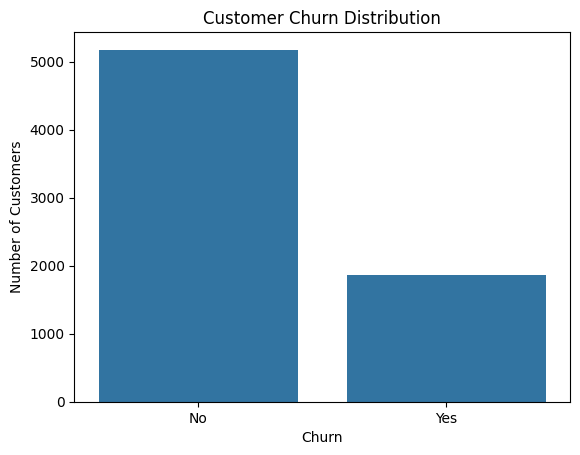

In [18]:
# Visualize Churn
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [20]:
# Clean TotalCharges
df['TotalCharges'].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: object

In [21]:
# Convert TotalCharges to Numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [22]:
# Check Missing Values Again
df['TotalCharges'].isnull().sum()

np.int64(11)

In [25]:
# Handle Missing Values
df.dropna(subset=['TotalCharges'], inplace=True)
df.shape

(7032, 21)

In [26]:
# Check Missing Values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [27]:
# Convert Churn to 0 and 1
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [28]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [29]:
# Separate X and y
# X = input features  y = target

In [30]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [31]:
X.shape

(7032, 20)

In [32]:
y.shape

(7032,)

In [33]:
# Remove Customer ID
X = X.drop('customerID', axis=1)

In [35]:
# Find Categorical Columns
X.select_dtypes(include='object').columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [36]:
# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [37]:
X.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [38]:
# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64

In [42]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [43]:
scaler.transform(X_test)

array([[-0.43931886,  1.07731992,  0.36373803, ...,  1.90515869,
        -0.71617747, -0.5394682 ],
       [-0.43931886, -1.0416488 ,  0.45009965, ..., -0.52489066,
        -0.71617747, -0.5394682 ],
       [-0.43931886,  0.87357292, -1.49137604, ..., -0.52489066,
        -0.71617747,  1.85367739],
       ...,
       [-0.43931886, -1.20464639, -1.51296645, ..., -0.52489066,
        -0.71617747,  1.85367739],
       [-0.43931886,  0.18083315, -0.81210867, ..., -0.52489066,
        -0.71617747,  1.85367739],
       [-0.43931886,  0.71057533, -1.48971524, ...,  1.90515869,
        -0.71617747, -0.5394682 ]], shape=(1407, 30))

In [44]:
scaler.fit_transform(X_train)

array([[-0.43931886,  1.3218163 ,  0.98155578, ...,  1.90515869,
        -0.71617747, -0.5394682 ],
       [-0.43931886, -0.26741023, -0.97154551, ..., -0.52489066,
         1.39630196, -0.5394682 ],
       [-0.43931886,  1.4440645 ,  0.83706615, ...,  1.90515869,
        -0.71617747, -0.5394682 ],
       ...,
       [-0.43931886,  0.14008375,  0.92674937, ...,  1.90515869,
        -0.71617747, -0.5394682 ],
       [-0.43931886, -0.9194006 ,  0.02991714, ..., -0.52489066,
        -0.71617747,  1.85367739],
       [ 2.27625101, -1.28614519,  0.32221802, ..., -0.52489066,
         1.39630196, -0.5394682 ]], shape=(5625, 30))

In [45]:
# Create Logistic Regression Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [46]:
model

LogisticRegression(max_iter=1000)

In [47]:
# Train Model
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [48]:
# Make Predictions
y_pred = model.predict(X_test_scaled)

In [49]:
y_pred[:20]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0])

In [50]:
# Accuracy
from sklearn.metrics import accuracy_score

In [51]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8038379530916845


In [52]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6475903614457831


In [53]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.5748663101604278


In [54]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.6090651558073654


In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[916 117]
 [159 215]]


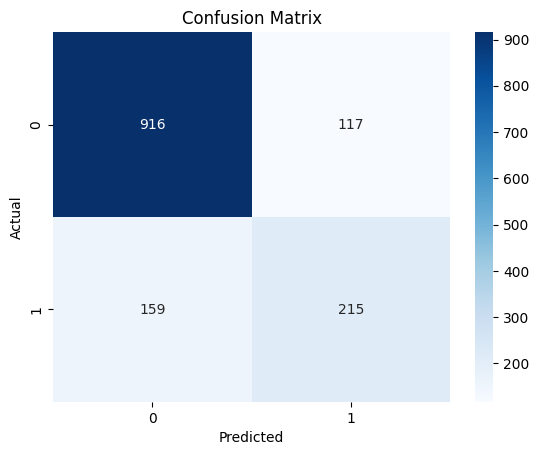

In [56]:
#visualize confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [58]:
# Get Churn Probability
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_prob[:10]

array([0.01711495, 0.59613179, 0.00476432, 0.20004408, 0.10022205,
       0.4700293 , 0.02661132, 0.16414898, 0.68614136, 0.01518016])

In [59]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8356727976766699


In [60]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

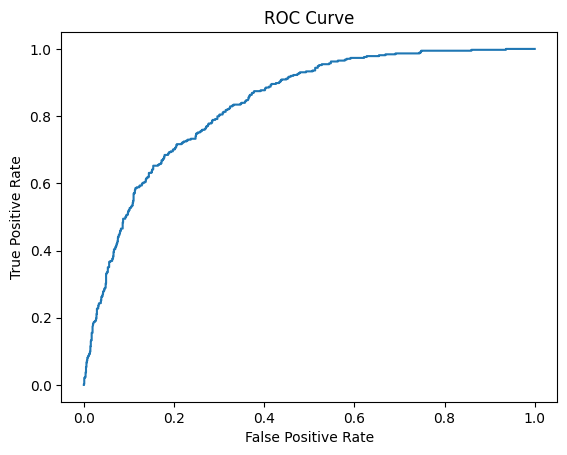

In [61]:
plt.plot(fpr, tpr)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.show()

Conclusion:
In this project, we predicted customer churn using Logistic Regression.
We cleaned the data, handled missing values, encoded categorical features, and scaled numerical data.
We evaluated the model using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
Recall was important because identifying customers likely to churn helps the company retain them.